In [ ]:
# Install OpenCV
!pip install opencv-python-headless

# Install NumPy (usually pre-installed with Jupyter)
!pip install numpy

# Install Matplotlib
!pip install matplotlib

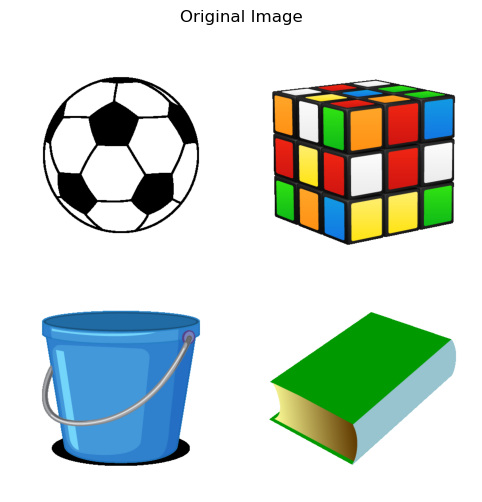

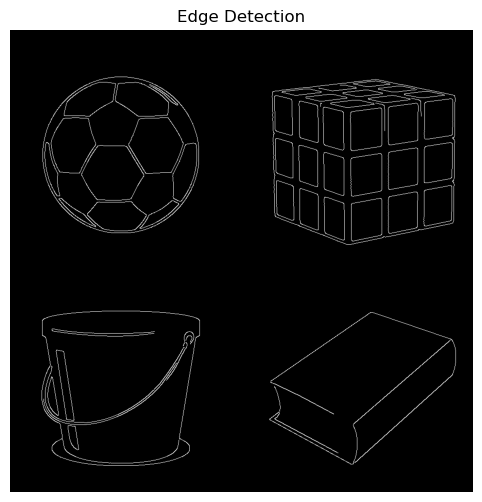

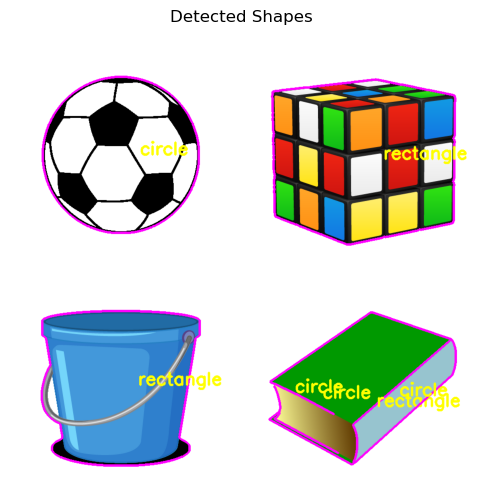

In [2]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = 'C:\\Users\\srini\\Downloads\\77.png'
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the original image
plt.figure(figsize=(8, 6))
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Step 1: Apply Gaussian blur to reduce noise and detail in the image
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 2: Perform edge detection using Canny
edges = cv2.Canny(blurred, 50, 150)

# Display edges
plt.figure(figsize=(8, 6))
plt.title("Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

# Step 3: Find contours in the edged image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 4: Draw contours and identify shapes
def detect_shape(c):
    # Initialize shape name
    shape = "unidentified"
    # Calculate perimeter
    peri = cv2.arcLength(c, True)
    # Approximate the shape
    approx = cv2.approxPolyDP(c, 0.04 * peri, True)
    # Triangle
    if len(approx) == 3:
        shape = "triangle"
    # Square or Rectangle
    elif len(approx) == 4:
        (x, y, w, h) = cv2.boundingRect(approx)
        ar = w / float(h)
        shape = "square" if 0.95 <= ar <= 1.05 else "rectangle"
    # Pentagon
    elif len(approx) == 5:
        shape = "pentagon"
    # Circle
    else:
        shape = "circle"
    return shape

# Create a copy of the original image to draw shapes
output = image.copy()

# Loop over the contours
for contour in contours:
    # Compute the center of the contour
    M = cv2.moments(contour)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0

    # Detect the shape of the contour and draw it on the output image
    shape = detect_shape(contour)
    cv2.drawContours(output, [contour], -1, (255, 0, 255), 3)  # Bright magenta contour color
    
    # Draw the label to the right of the detected shape
    cv2.putText(output, shape, (cX + 40, cY),  # Offset position to the right of shape
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 3)  # Yellow color, larger font size

# Display the output image with detected shapes
plt.figure(figsize=(8, 6))
plt.title("Detected Shapes")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()